# <span style="color: yellow;">Master Notebook - ResNet50</span>

Since Greg wants a single notebook, we should organize everything into one organized, sequential notebook you can just run rom the start.  It'll have different sections for each compression algorithm and plot the results at the end on a Pareto front.

Please paste your functions applying your compression technique in the appropriate section.  The final deliverable is a <ins>Pareto Front</ins> graph, so what you need to output from your model is its <ins>% size reduction</ins> (how much you decreased parameters) and <ins>F1 accuracy</ins> at that size.

**Table of Contents:**
1. <ins>Data Preparation:</ins> this section pulls the necessary dataset from huggingface and instantiates a pytorch dataset/loaders
2. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)
3. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP
4. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm
5. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

In [1]:
# first we just ensure we are working in the right folder
import os
target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if not os.getcwd().endswith(target_folder):
    os.chdir(path)

print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/kod6/CS6423_knowledge_distillation_project


## <span style="color: yellow;">1. Data Preparation</span>

In [2]:
# Fiachra - code that downloads the dataset and organizes the csv.

Here we prepare the dataset using Fiachra's modules:

In [3]:
# Fiachra - instantiate the dataset/dataloaders through the datasetPrepper
import pandas as pd
from modules.dataset_prepper import datasetPrepper

# sets path variables
pretrained_weights_path = "RadImageNet_weights/resnet50.pth"
dataframe_path = "data/labels.csv"
image_dir = "data/test_images"
model_name = "resnet50_baseline_cpu"

# loads dataset csv
dataframe = pd.read_csv(dataframe_path)
num_classes = dataframe["label"].nunique()

# prepare dataset with datasetPrepper module, print confirmations
data_prep = datasetPrepper(
    dataframe_path="data/labels.csv",
    image_dir="data/test_images",
).prepare(compute_class_weights=True)

print(f"Dataset prepared:")
print(f"  Train samples: {len(data_prep.train_dataset)}")
print(f"  Val samples: {len(data_prep.val_dataset)}")
print(f"  Test samples: {len(data_prep.test_dataset)}")
print(f"  Classes: {len(data_prep.class_names)}")

Dataset prepared:
  Train samples: 7948
  Val samples: 1590
  Test samples: 398
  Classes: 61


## <span style="color: yellow;">2. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface read token for the model repo.

In [4]:
from huggingface_hub import snapshot_download, login
login("YOUR_HF_TOKEN_HERE")  # replace with your own HuggingFace token

snapshot_download(
    repo_id="fiabar/cs6423_model_repo",
    repo_type="model",
    local_dir=os.path.join(os.getcwd(), 'trained_models/')
)

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

'/home/kod6/CS6423_knowledge_distillation_project/trained_models'

Here we instantiate the pretrained ResNet50 and run an inference pass for the baseline.

In [5]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet50 = resnet50.to(device)
resnet50.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet50.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet50, "ResNet50 gpu new")
print(f'Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}')


Warming up ResNet50 gpu new...
Running inference...
Our F1 score: 0.49377259670043605
Our total parameters: 23633021


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## <span style="color: yellow;">3. Basic Compression Algorithms</span>

### Initializing our experiment tracker
Here we define a function that can append the results from each model compression algorithm to a dataframe for our Pareto Front visualization.  The tracker has:
* method: the method you used for compression (e.g., LTH, RGP, NAS+KD, etc.)
* base_model: the name of the model you are compressing (e.g., resnet10, resnet18, resnet50) 
* base_size: the number of parameters in the basic model
* compressed_size: the number of parameters in the model you compressed
* f1: the F1 score your compressed model has 

So, after you run each experiment, have something that looks like:

In [6]:
'''
Method = 'Pruning'
Base_Model = 'resnet10'
Base_Model_Parameters = 2012345
New_Model_Parameters = 2002345
F1_Score = 0.8
add_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)
'''

"\nMethod = 'Pruning'\nBase_Model = 'resnet10'\nBase_Model_Parameters = 2012345\nNew_Model_Parameters = 2002345\nF1_Score = 0.8\nadd_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)\n"

In [7]:
# initialize a dataframe we will append our results to
results_df = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet50', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.494


In [8]:
# Code or functions that apply basic pruning
from torch.nn.utils import prune
import copy

def random_prune(model, amount):
    # apply ranodm unstructured pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.random_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'randomized unstructured pruning applied with amount: {amount}')

def magnitude_prune(model, amount):
    # apply random magnitude pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.l1_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'magnitude pruning applied with amount: {amount}')


pruning_amounts = [0.05, 0.1, 0.15]
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

for amount in pruning_amounts:
    # initialize model copies
    model_random_pruned = copy.deepcopy(resnet50)
    model_magnitude_pruned = copy.deepcopy(resnet50)
    
    # apply prunings and record results
    random_prune(model_random_pruned, amount)
    metrics = evaluator.evaluate_single(model_random_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Random Pruning', 
                   base_model='resnet50',
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])
    
    magnitude_prune(model_magnitude_pruned, amount)
    metrics = evaluator.evaluate_single(model_magnitude_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Magnitude Pruning', 
                   base_model='resnet50', 
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])

display(results_df)

Logged: Random Pruning | Reduction: 5.0% | F1: 0.024


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 5.0% | F1: 0.494


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 10.0% | F1: 0.037


...

Logged: Random Pruning | Reduction: 15.0% | F1: 0.003


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 15.0% | F1: 0.499


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Method,Base_Model,Size_Reduction_Pct,F1_Score
0,N/A,resnet50,0.0,0.4938
1,Random Pruning,resnet50,4.99,0.024
2,Magnitude Pruning,resnet50,4.99,0.4938
3,Random Pruning,resnet50,9.98,0.0371
4,Magnitude Pruning,resnet50,9.98,0.4967
5,Random Pruning,resnet50,14.97,0.0032
6,Magnitude Pruning,resnet50,14.97,0.4986


### Basic Pruning and Quantization

In [9]:
# Code or functions that apply quantization

### Caylum - Lottery Ticket Hypothesis
Sentence or two to explain your method, then your code.

In [10]:
# Caylum - code or functions that apply LTH and output a few datapoints for the Pareto Front
# append to the dataframe as described above

### Kellie - RGP
Code/functions that apply RGP and output a few datapoints for the Pareto Front. RGP iteratively removes the least important convolution filters from ResNet50 using gradient-based importane scorea, sheinking the model in 5 steps from 10% to 50% sparsity. After each pruning step the model is fine-tunes to recover accuracy, trading off model size against F1 score acrpss 5 Pareto front points.

In [11]:
# Kellie - RGP: Rigorous Gradient-based Pruning
#
# RGP iteratively removes the least important convolutional filters from ResNet50
# using gradient-based importance scores, shrinking the model in 5 steps from 10%
# to 50% sparsity. After each pruning step the model is fine-tuned to recover
# accuracy, trading off model size against F1 score across 5 Pareto front points.
#
# The process repeats 5 times, each time:
#   A. SCORE   - run a few training batches to measure which filters contribute
#                least to the loss using a gradient-based importance score (DFOT)
#   B. PRUNE   - permanently remove the lowest-scoring 10% of eligible filters,
#                also updating the next layer's input channels to match
#   C. RECOVER - fine-tune the pruned model for 10 epochs to regain accuracy
#
# After each iteration we log F1 and size reduction to the shared results_df,
# giving 5 data points on the Pareto front (10%, 20%, 30%, 40%, 50% sparsity).
#
# Two layer types are always protected from pruning:
#   - conv3 layers (the final 1x1 conv in each ResNet bottleneck block)
#   - downsample layers (the skip connection projections)
#   - stem conv1 (the very first layer - its skip connections are too complex to patch)
# These are skip-connected, meaning pruning their output channels would break the
# residual addition that ResNet depends on.

import copy
import torch.nn as nn
from modules.model_trainer import modelTrainer

# --- 1. DFOT SCORER ---
# Computes a gradient-based importance score for each filter.
# For each filter, it multiplies the weight by its gradient and takes the
# magnitude - filters that have large gradients on large weights are important.
# Alpha=0.5 softens (desensitizes) the scores so pruning isn't too aggressive.

class DFOTScorer:
    def __init__(self, model, alpha=0.5):
        self.model, self.alpha = model, alpha
        self._hooks, self._bufs, self._counts = [], {}, {}

    def register_hooks(self):
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                h = module.weight.register_hook(self._make_hook(name, module))
                self._hooks.append(h); self._bufs[name] = None; self._counts[name] = 0

    def _make_hook(self, name, module):
        def hook(grad):
            with torch.no_grad():
                raw = (module.weight.detach() * grad).abs().pow(self.alpha)
                f_scores = raw.view(raw.shape[0], -1).sum(dim=1)
                if self._bufs[name] is None: self._bufs[name] = f_scores.clone()
                else: self._bufs[name] += f_scores
                self._counts[name] += 1
        return hook

    def get_scores(self):
        return {n: (b / max(self._counts[n], 1)) for n, b in self._bufs.items() if b is not None}

    def remove_hooks(self):
        for h in self._hooks: h.remove()
        self._hooks = []


# --- 2. FILTER SELECTION ---
# Ranks all eligible filters across all eligible layers by their DFOT score
# and selects the bottom prune_ratio fraction for removal.
# Tracks previously pruned filters in pruning_mask so we never try to prune
# a filter that has already been removed in a previous iteration.

def get_filters_to_prune(scores, prune_ratio, protected_layers, pruning_mask):
    all_entries = []
    for layer_name, filter_scores in scores.items():
        if any(x in layer_name for x in ["conv3", "downsample"]) or layer_name in protected_layers:
            continue
        already_pruned = pruning_mask.get(layer_name, [])
        for f_idx, score in enumerate(filter_scores.cpu().tolist()):
            if f_idx not in already_pruned:
                all_entries.append((score, layer_name, f_idx))
    all_entries.sort(key=lambda x: x[0])
    n_prune = int(len(all_entries) * prune_ratio)
    prune_map = {}
    for _, layer_name, f_idx in all_entries[:n_prune]:
        prune_map.setdefault(layer_name, []).append(f_idx)
    return prune_map


# --- 3. STRUCTURED PRUNING ---
# Actually removes the selected filters from the model by rebuilding each
# affected Conv2d with fewer output channels. Also updates:
#   - The corresponding BatchNorm layer (must match conv output channels)
#   - The NEXT layer's input channels (must match conv output channels)
# This is what makes it "structured" - the model architecture changes and
# the weight tensors get physically smaller, giving real speedup and size reduction.

def structured_prune(model, prune_map):

    def set_module(model, name, new_module):
        parts = name.split(".")
        parent = model
        for p in parts[:-1]: parent = getattr(parent, p)
        setattr(parent, parts[-1], new_module)

    def get_module(model, name):
        m = model
        for p in name.split("."): m = getattr(m, p)
        return m

    def prune_conv_out(conv, keep):
        new = nn.Conv2d(conv.in_channels, len(keep), conv.kernel_size,
                        stride=conv.stride, padding=conv.padding, bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[keep])
            if conv.bias is not None: new.bias.copy_(conv.bias[keep])
        return new

    def prune_conv_in(conv, keep):
        new = nn.Conv2d(len(keep), conv.out_channels, conv.kernel_size,
                        stride=conv.stride, padding=conv.padding, bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[:, keep, :, :])
            if conv.bias is not None: new.bias.copy_(conv.bias)
        return new

    def prune_bn(bn, keep):
        new = nn.BatchNorm2d(len(keep))
        with torch.no_grad():
            new.weight.copy_(bn.weight[keep])
            new.bias.copy_(bn.bias[keep])
            new.running_mean.copy_(bn.running_mean[keep])
            new.running_var.copy_(bn.running_var[keep])
        return new

    for layer_name, prune_indices in prune_map.items():
        # skip ResNet skip-connection layers - pruning these breaks residual addition
        if "conv3" in layer_name or "downsample" in layer_name:
            continue

        # skip stem conv1 - feeds into layer1 skip connections, too complex to patch
        if layer_name == "conv1":
            print(f"  Skipping stem conv1 — protected")
            continue

        try:
            conv = get_module(model, layer_name)
        except AttributeError:
            continue
        if not isinstance(conv, nn.Conv2d):
            continue

        keep = [i for i in range(conv.out_channels) if i not in prune_indices]
        if not keep:
            continue

        set_module(model, layer_name, prune_conv_out(conv, keep))

        # update BatchNorm to match new number of output channels
        bn_name = layer_name.replace("conv1", "bn1") if "conv1" in layer_name else \
                  layer_name.replace("conv2", "bn2") if "conv2" in layer_name else None
        if bn_name:
            try:
                bn = get_module(model, bn_name)
                if isinstance(bn, nn.BatchNorm2d):
                    set_module(model, bn_name, prune_bn(bn, keep))
            except AttributeError:
                pass

        # update the next conv layer's input channels to match
        parts = layer_name.split(".")
        if len(parts) == 3:
            layer_group, block_idx, conv_num = parts
            next_name = f"{layer_group}.{block_idx}.conv2" if conv_num == "conv1" else \
                        f"{layer_group}.{block_idx}.conv3" if conv_num == "conv2" else None
            if next_name:
                try:
                    next_conv = get_module(model, next_name)
                    if isinstance(next_conv, nn.Conv2d):
                        set_module(model, next_name, prune_conv_in(next_conv, keep))
                except AttributeError:
                    pass

        pruning_mask[layer_name] = prune_indices

    total = sum(len(v) for v in pruning_mask.values())
    print(f"  Total filters removed: {total}")
    return model


# --- 4. MAIN EXECUTION LOOP ---
# deepcopy so we never modify the original resnet50 baseline
# re-enable gradients since resnet50 was frozen in the loading cell

rgp_model = copy.deepcopy(resnet50).to(device)
for p in rgp_model.parameters():
    p.requires_grad = True

initial_params = sum(p.numel() for p in rgp_model.parameters())
criterion      = nn.CrossEntropyLoss(weight=data_prep.class_weights.to(device))
pruning_mask   = {}
rgp_step_metrics = []

for target in [0.10, 0.20, 0.30, 0.40, 0.50]:
    print(f"\n--- RGP Iteration: {target*100:.0f}% Sparsity ---")

    # A. SCORE - run 15 batches to accumulate gradient-based filter importance scores
    scorer = DFOTScorer(rgp_model)
    scorer.register_hooks()
    rgp_model.train()
    for i, (imgs, labels) in enumerate(data_prep.train_loader):
        if i >= 15: break
        loss = criterion(rgp_model(imgs.to(device)), labels.to(device))
        loss.backward()

    # B. PRUNE - select and remove the bottom 10% of filters by DFOT score
    scores    = scorer.get_scores()
    scorer.remove_hooks()
    prune_map = get_filters_to_prune(scores, 0.10, [], pruning_mask)
    rgp_model = structured_prune(rgp_model, prune_map)

    # C. RECOVER - fine-tune for 10 epochs to regain accuracy after pruning
    trainer = modelTrainer(
        model=rgp_model,
        data_prep=data_prep,
        device=device,
        learn_rate=2e-4,
        num_epochs=10,
        model_name=f"rgp_step_{target}"
    )
    trainer.prepare_for_training()
    trainer.train_all()

    # log this step as a separate data point on the Pareto front
    step_metrics = evaluator.evaluate_single(rgp_model, f"RGP_{int(target*100)}pct")
    step_params  = sum(p.numel() for p in rgp_model.parameters())
    add_experiment(
        method='RGP',
        base_model='resnet50',
        base_size=initial_params,
        compressed_size=step_params,
        f1=step_metrics['f1_macro']
    )

    # store full metrics for summary table
    rgp_step_metrics.append({
        'Sparsity': f"{int(target*100)}%",
        'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

# --- 5. RESULTS SUMMARY TABLE ---
import pandas as pd
summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
summary_df.index.name = 'RGP Step'
display(summary_df)


--- RGP Iteration: 10% Sparsity ---
  Skipping stem conv1 — protected
  Total filters removed: 531


Validating: 100%|██████████| 50/50 [00:03<00:00, 15.09batch/s]



Epoch 1/10
Train Loss: 0.8551 | Train F1: 0.4692
Val Loss: 1.9852 | Val F1: 0.3280
Epoch Time: 35.98s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.82batch/s]



Epoch 2/10
Train Loss: 0.5779 | Train F1: 0.5549
Val Loss: 1.9198 | Val F1: 0.3318
Epoch Time: 35.89s



...

Validating: 100%|██████████| 50/50 [00:03<00:00, 15.07batch/s]


Epoch 10/10
Train Loss: 0.0951 | Train F1: 0.8049
Val Loss: 2.8761 | Val F1: 0.3690
Epoch Time: 36.58s



Logged: RGP | Reduction: 14.7% | F1: 0.328


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,4.48,0.3318,86.3,1.07
20%,7.24,0.3184,83.8,1.05
30%,9.66,0.3112,81.6,1.04
40%,12.56,0.3346,79.0,1.06
50%,14.65,0.3282,77.1,1.00


In [12]:
import subprocess
subprocess.run(["pip", "install", "seaborn"], check=True)

Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

## <span style="color: yellow;">4. Knowledge Distillation Algorithms</span>


### Ethan - NAS + KD Algorithm

In [14]:
# Ethan - code or functions that perform NAS + KD

### Ciara - PWKD
A few sentences to describe your method, then your code

In [15]:
# Ciara - code or functions that apply PWKD
# append results to the dataframe as described above

## <span style="color: yellow;">5. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

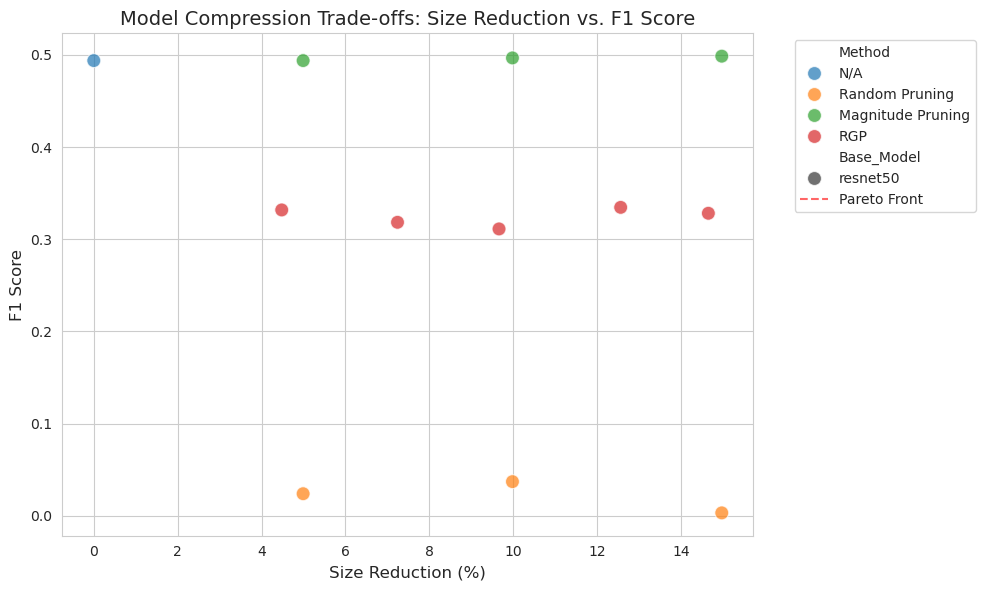

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        style='Base_Model',
        s=100, 
        alpha=0.7
    )
    
    # visualizes pareto frontier line
    plt.step(pareto_reduction, pareto_f1, where='post', color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()

plot_compression_pareto(results_df)